# RAVDESS EDA and Split Verification

This notebook is the first checkpoint for the project. It should help us verify:

- the raw `RAVDESS` speech files are in the expected place
- filename parsing is correct
- the 6-class label mapping is correct
- the speaker-independent split is correct
- we understand the dataset distribution before training anything


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.ravdess_metadata import build_ravdess_metadata, save_metadata
from src.utils.paths import RAW_DATA_DIR, METADATA_DIR

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RAW_DATA_DIR, METADATA_DIR


(PosixPath('/Users/pavan/Downloads/CSULA SEM2/DS/FinalProject/data/raw'),
 PosixPath('/Users/pavan/Downloads/CSULA SEM2/DS/FinalProject/data/metadata'))

## Expected Data Location

Place the raw `RAVDESS` dataset somewhere under:

- `data/raw/`

The metadata builder searches recursively for `.wav` files, so nested folders are okay.

In [2]:
metadata_path = METADATA_DIR / 'ravdess_metadata.csv'
df = build_ravdess_metadata(RAW_DATA_DIR)
save_metadata(df, metadata_path)

print(f'Saved metadata to: {metadata_path}')
print(f'Total speech clips found: {len(df)}')
print(f'Clips kept for 6-class project setup: {int(df["keep_for_project"].sum())}')

project_df = df[df['keep_for_project']].copy().reset_index(drop=True)
project_df.head()


Saved metadata to: /Users/pavan/Downloads/CSULA SEM2/DS/FinalProject/data/metadata/ravdess_metadata.csv
Total speech clips found: 1440
Clips kept for 6-class project setup: 1248


,file_name,file_path,modality_code,modality,channel_code,channel,emotion_code,emotion,intensity_code,intensity,...,repetition,actor_id,actor_gender,final_label,keep_for_project,sample_rate,num_frames,duration_seconds,num_channels,split
0,03-01-01-01-01-01-01.wav,/Users/pavan/Downloads/CSULA SEM2/DS/FinalProj...,03,audio_only,01,speech,01,neutral,01,normal,...,first,01,male,neutral,True,48000,158558,3.303292,1,train
1,03-01-01-01-01-02-01.wav,/Users/pavan/Downloads/CSULA SEM2/DS/FinalProj...,03,audio_only,01,speech,01,neutral,01,normal,...,second,01,male,neutral,True,48000,160160,3.336667,1,train
2,03-01-01-01-02-01-01.wav,/Users/pavan/Downloads/CSULA SEM2/DS/FinalProj...,03,audio_only,01,speech,01,neutral,01,normal,...,first,01,male,neutral,True,48000,156956,3.269917,1,train
3,03-01-01-01-02-02-01.wav,/Users/pavan/Downloads/CSULA SEM2/DS/FinalProj...,03,audio_only,01,speech,01,neutral,01,normal,...,second,01,male,neutral,True,48000,152152,3.169833,1,train
4,03-01-02-01-01-01-01.wav,/Users/pavan/Downloads/CSULA SEM2/DS/FinalProj...,03,audio_only,01,speech,02,calm,01,normal,...,first,01,male,neutral,True,48000,169769,3.536854,1,train


In [3]:
df[['file_name', 'emotion', 'final_label', 'intensity', 'statement', 'actor_id', 'split']].head(10)


,file_name,emotion,final_label,intensity,statement,actor_id,split
0,03-01-01-01-01-01-01.wav,neutral,neutral,normal,Kids are talking by the door,01,train
1,03-01-01-01-01-02-01.wav,neutral,neutral,normal,Kids are talking by the door,01,train
2,03-01-01-01-02-01-01.wav,neutral,neutral,normal,Dogs are sitting by the door,01,train
3,03-01-01-01-02-02-01.wav,neutral,neutral,normal,Dogs are sitting by the door,01,train
4,03-01-02-01-01-01-01.wav,calm,neutral,normal,Kids are talking by the door,01,train
5,03-01-02-02-01-01-01.wav,calm,neutral,strong,Kids are talking by the door,01,train
6,03-01-02-01-01-02-01.wav,calm,neutral,normal,Kids are talking by the door,01,train
7,03-01-02-02-01-02-01.wav,calm,neutral,strong,Kids are talking by the door,01,train
8,03-01-02-01-02-01-01.wav,calm,neutral,normal,Dogs are sitting by the door,01,train
9,03-01-02-02-02-01-01.wav,calm,neutral,strong,Dogs are sitting by the door,01,train


## Original Label Counts

In [4]:
emotion_counts = df['emotion'].value_counts().rename_axis('emotion').reset_index(name='count')
emotion_counts


,emotion,count
0,calm,192
1,happy,192
2,sad,192
3,angry,192
4,fearful,192
5,disgust,192
6,surprised,192
7,neutral,96


/var/folders/nh/bm0b58nx13n8tjfb7xq852t40000gn/T/ipykernel_54657/3722526824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index, palette='viridis')


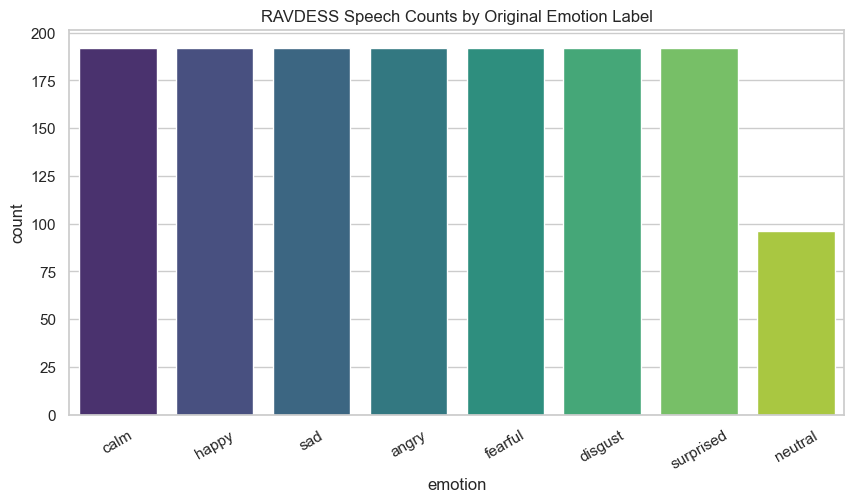

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index, palette='viridis')
plt.title('RAVDESS Speech Counts by Original Emotion Label')
plt.xticks(rotation=30)
plt.show()


## Final 6-Class Label Counts

In [6]:
final_counts = project_df['final_label'].value_counts().rename_axis('final_label').reset_index(name='count')
final_counts


,final_label,count
0,neutral,288
1,happy,192
2,sad,192
3,angry,192
4,fearful,192
5,disgust,192


/var/folders/nh/bm0b58nx13n8tjfb7xq852t40000gn/T/ipykernel_54657/707557699.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=project_df, x='final_label', order=project_df['final_label'].value_counts().index, palette='magma')


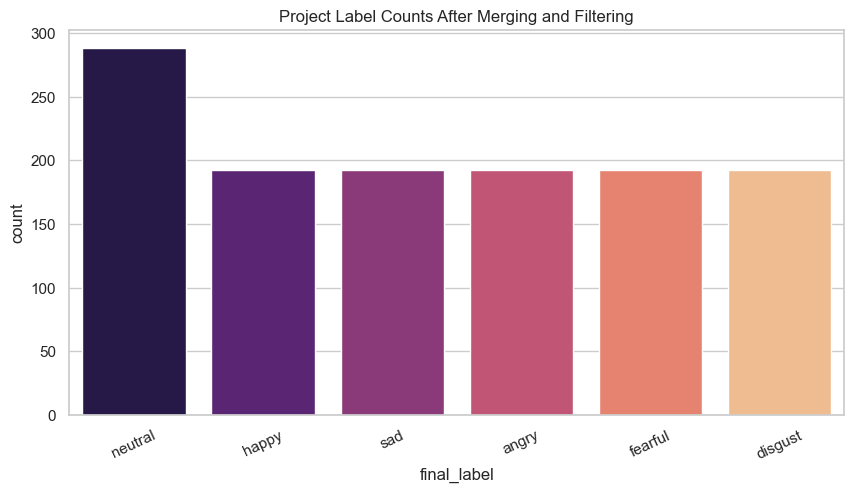

In [7]:
plt.figure(figsize=(10, 5))
sns.countplot(data=project_df, x='final_label', order=project_df['final_label'].value_counts().index, palette='magma')
plt.title('Project Label Counts After Merging and Filtering')
plt.xticks(rotation=25)
plt.show()


## Split Verification

In [8]:
split_actor_table = project_df.groupby('split')['actor_id'].unique().apply(list)
split_actor_table


split
test                                      [21, 22, 23, 24]
train    [01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 1...
val                                       [17, 18, 19, 20]
Name: actor_id, dtype: object

In [9]:
project_df.groupby(['split', 'final_label']).size().unstack(fill_value=0)


final_label,angry,disgust,fearful,happy,neutral,sad
split,,,,,,
test,32,32,32,32,48,32
train,128,128,128,128,192,128
val,32,32,32,32,48,32


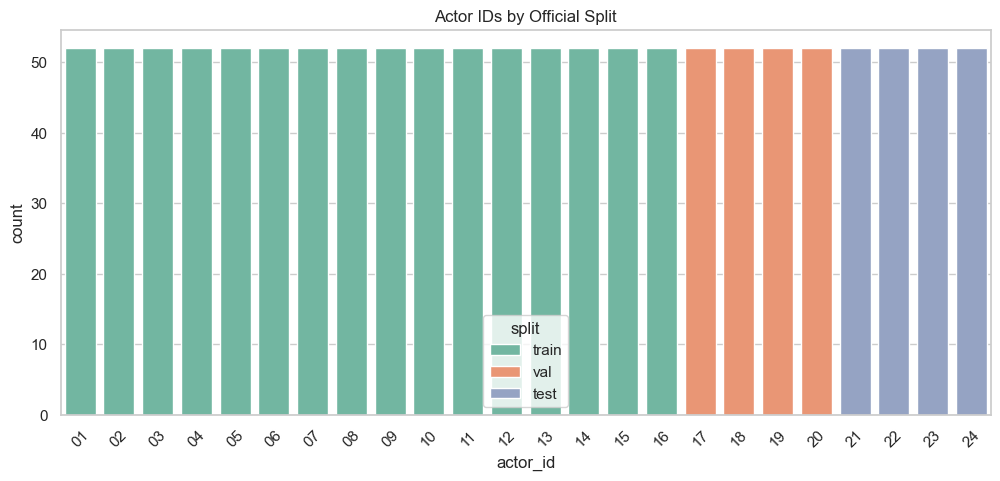

In [10]:
plt.figure(figsize=(12, 5))
sns.countplot(data=project_df, x='actor_id', hue='split', dodge=False, palette='Set2')
plt.title('Actor IDs by Official Split')
plt.xticks(rotation=45)
plt.show()


## Duration Analysis

In [11]:
project_df['duration_seconds'].describe()


count    1248.000000
mean        3.733458
std         0.337601
min         2.936271
25%         3.503500
50%         3.703708
75%         3.903917
max         5.271937
Name: duration_seconds, dtype: float64

/var/folders/nh/bm0b58nx13n8tjfb7xq852t40000gn/T/ipykernel_54657/1031790317.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=project_df, x='final_label', y='duration_seconds', ax=axes[1], palette='coolwarm')


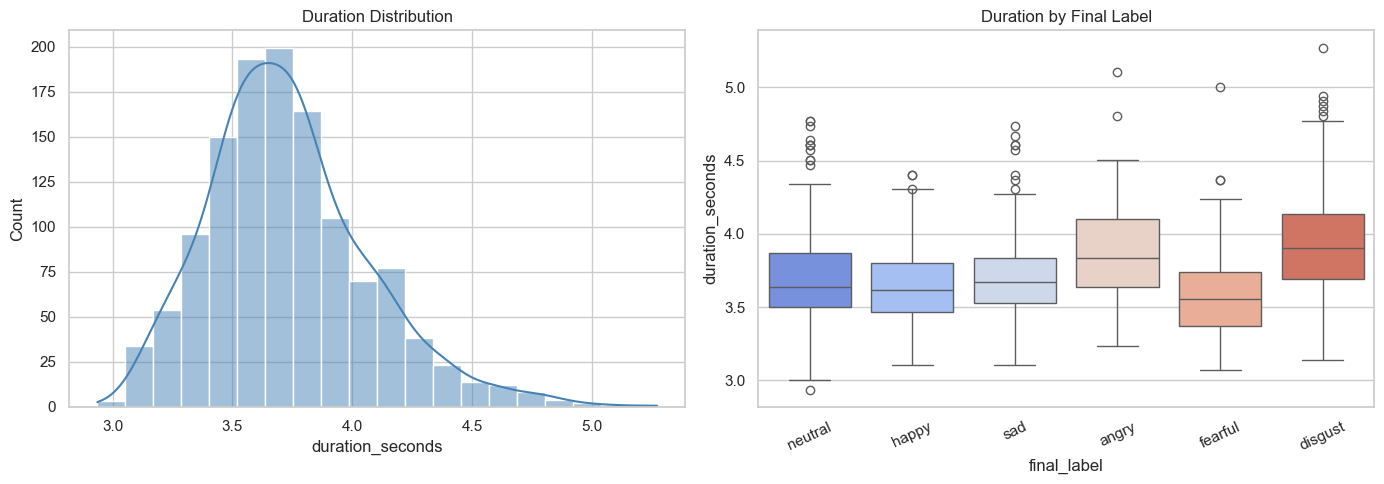

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(project_df['duration_seconds'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Duration Distribution')

sns.boxplot(data=project_df, x='final_label', y='duration_seconds', ax=axes[1], palette='coolwarm')
axes[1].set_title('Duration by Final Label')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()


## Statement and Intensity Checks

In [13]:
project_df.groupby(['statement', 'final_label']).size().unstack(fill_value=0)


final_label,angry,disgust,fearful,happy,neutral,sad
statement,,,,,,
Dogs are sitting by the door,96,96,96,96,144,96
Kids are talking by the door,96,96,96,96,144,96


In [14]:
project_df.groupby(['final_label', 'intensity']).size().unstack(fill_value=0)


intensity,normal,strong
final_label,,
angry,96,96
disgust,96,96
fearful,96,96
happy,96,96
neutral,192,96
sad,96,96


## Waveform and Spectrogram Samples

In [15]:
def plot_waveform_and_mel(example_row: pd.Series, sample_rate: int = 16000) -> None:
    audio_path = Path(example_row['file_path'])
    y, sr = librosa.load(audio_path, sr=sample_rate)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=lambda x: x.max())

    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    librosa.display.waveshow(y, sr=sr, ax=axes[0], color='teal')
    axes[0].set_title(
        f"Waveform | label={example_row['final_label']} | actor={example_row['actor_id']} | statement={example_row['statement_code']}"
    )

    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1], cmap='magma')
    axes[1].set_title('64-bin Log-Mel Spectrogram')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    plt.tight_layout()
    plt.show()


In [16]:
sample_rows = project_df.groupby('final_label', group_keys=False).head(1)
sample_rows[['final_label', 'actor_id', 'statement', 'file_name']]


,final_label,actor_id,statement,file_name
0,neutral,01,Kids are talking by the door,03-01-01-01-01-01-01.wav
12,happy,01,Kids are talking by the door,03-01-03-01-01-01-01.wav
20,sad,01,Kids are talking by the door,03-01-04-01-01-01-01.wav
28,angry,01,Kids are talking by the door,03-01-05-01-01-01-01.wav
36,fearful,01,Kids are talking by the door,03-01-06-01-01-01-01.wav
44,disgust,01,Kids are talking by the door,03-01-07-01-01-01-01.wav


/Users/pavan/Downloads/CSULA SEM2/DS/FinalProject/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


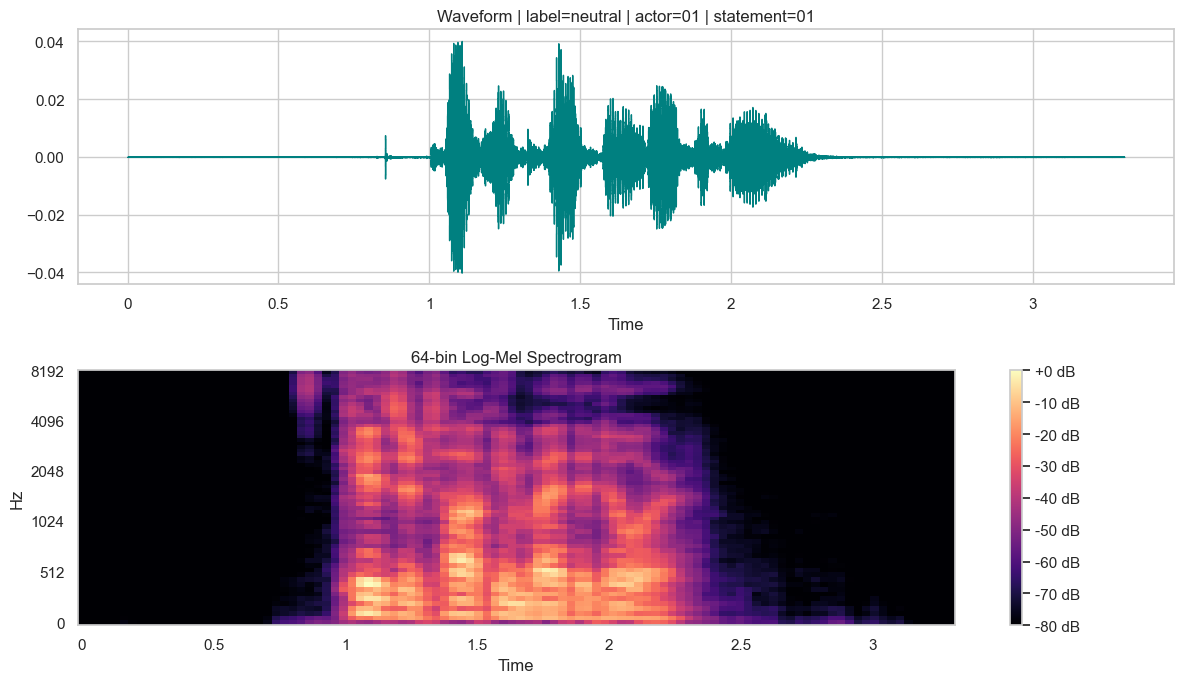

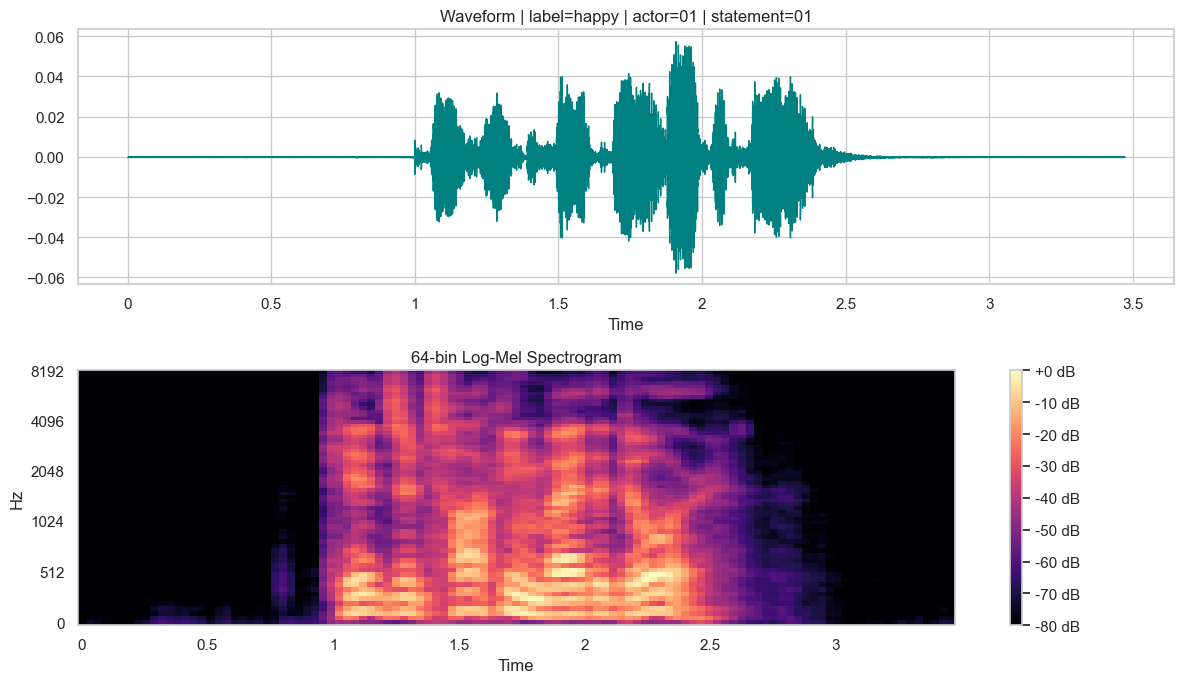

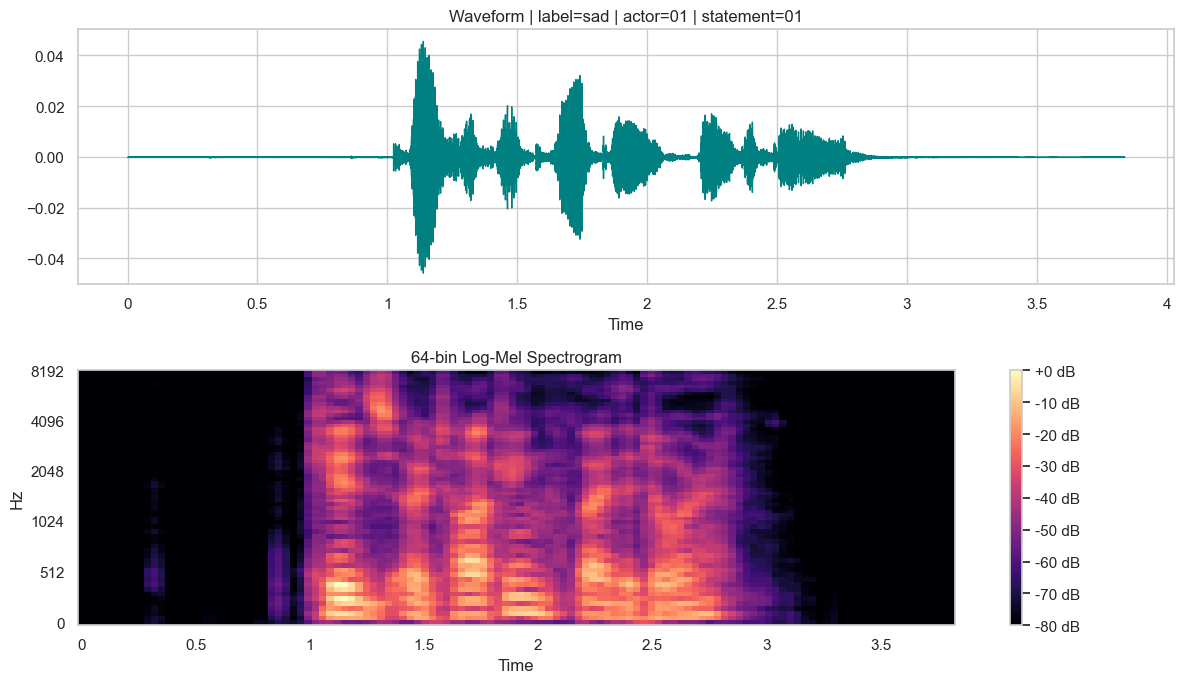

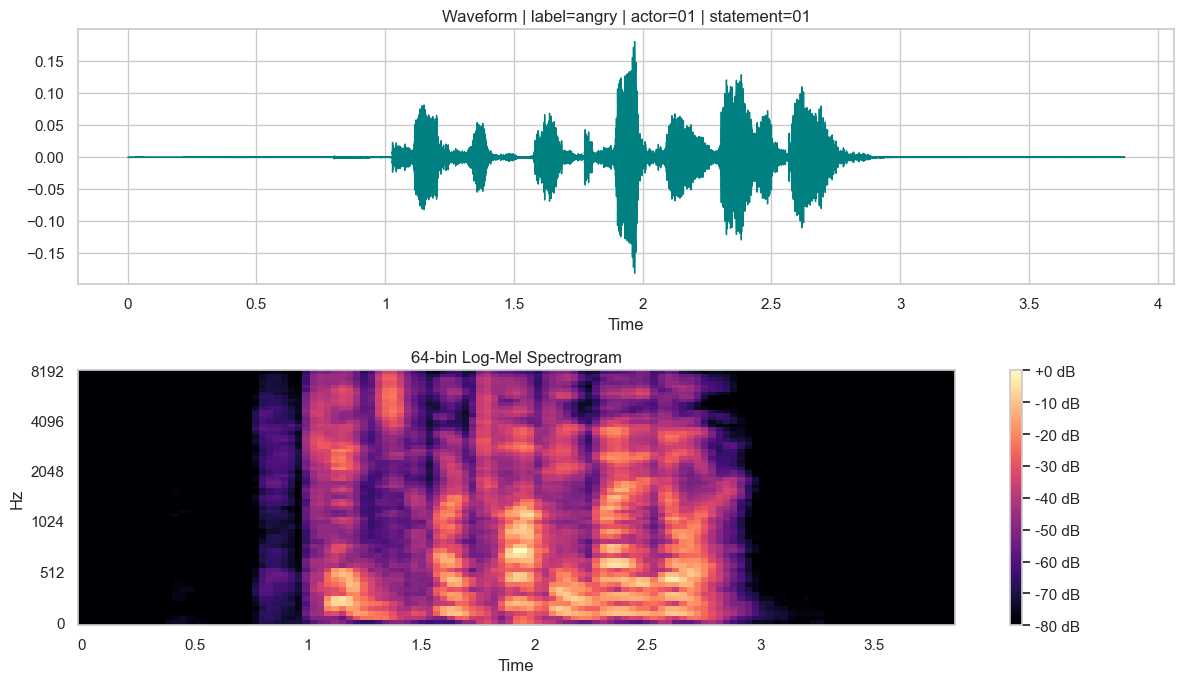

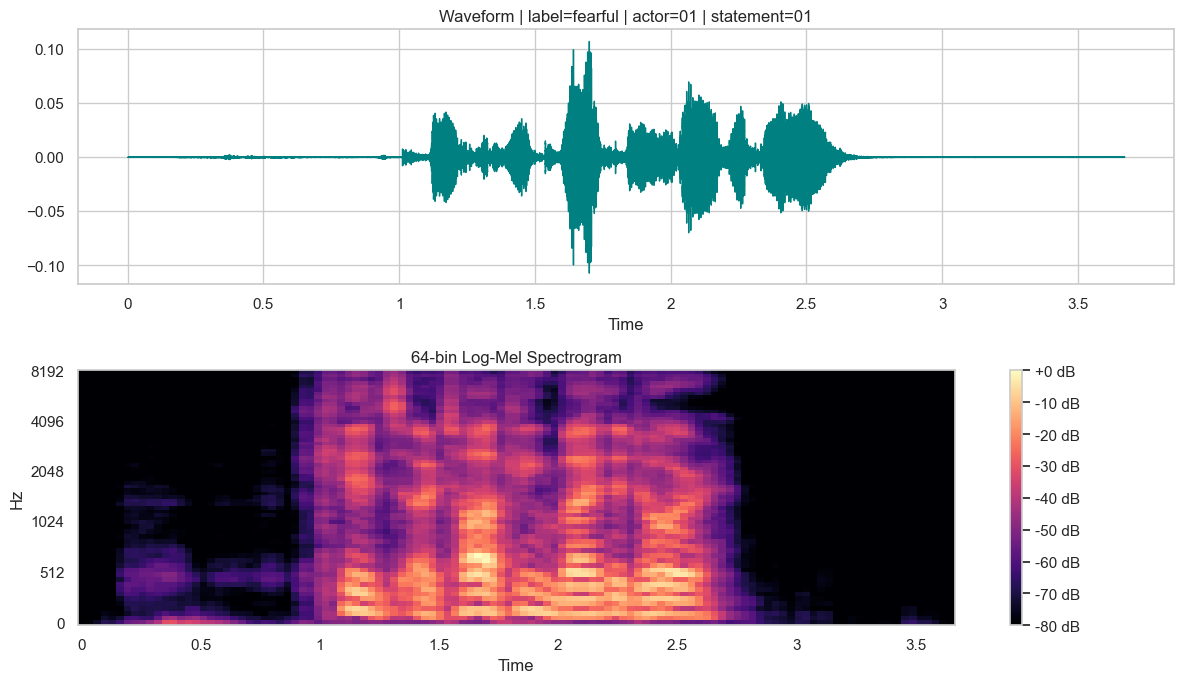

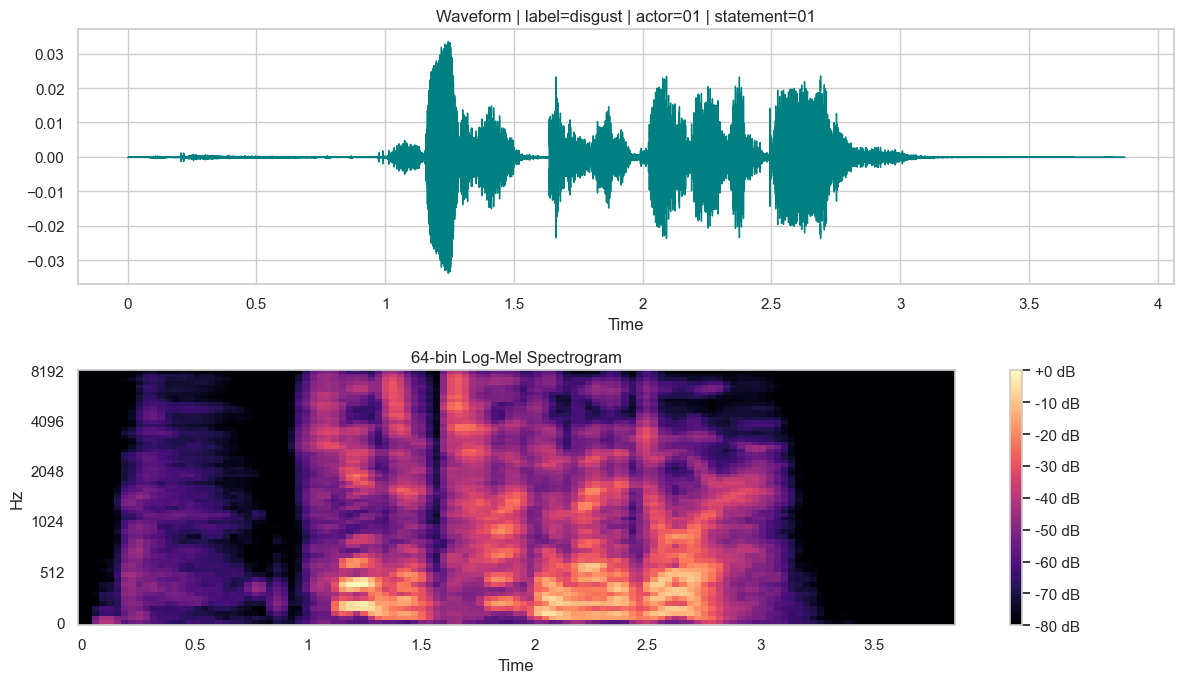

In [17]:
for _, row in sample_rows.iterrows():
    plot_waveform_and_mel(row)


## Next Questions Before Training

After this notebook runs cleanly, we should be able to answer:

- Is the official speaker-independent split correct?
- Do the merged labels look sensible?
- Are durations consistent enough for wav2vec2 batching?
- Do the waveform and spectrogram examples look clean?
- Are there any unexpected confounds we should note before fine-tuning?
